# Minor Project 1: Breast Cancer Diagnosis Prediction
### Supervised Machine Learning Classification

**Problem Statement:** Build a supervised machine learning model that predicts whether a breast tumor is **malignant** or **benign** based on diagnostic measurements derived from digitized images of fine needle aspirate (FNA) biopsies. Early and accurate diagnosis can support clinicians in prioritizing treatment.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset — originally published by the UCI Machine Learning Repository, and also mirrored on Kaggle. For reproducibility this notebook loads it via `sklearn.datasets.load_breast_cancer`, which contains the identical 569-sample, 30-feature dataset.

- UCI source: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Kaggle mirror: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

**Workflow:** Data Loading → EDA → Preprocessing → Model Training (Logistic Regression, Random Forest) → Evaluation → Conclusion

## 1. Import Libraries

In [1]:
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load Dataset

In [2]:
bc = load_breast_cancer(as_frame=True)
df = bc.frame.copy()
df.rename(columns={"target": "diagnosis"}, inplace=True)
df["diagnosis_label"] = df["diagnosis"].map({0: "malignant", 1: "benign"})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 32)


In [3]:
df.to_csv("../data/breast_cancer.csv", index=False)
print("Dataset saved to data/breast_cancer.csv")

Dataset saved to data/breast_cancer.csv


## 3. Exploratory Data Analysis (EDA)

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print(df["diagnosis_label"].value_counts())

Missing values: 0
Duplicate rows: 0

diagnosis_label
benign       357
malignant    212
Name: count, dtype: int64


There are **no missing values** and **no duplicate rows** in this dataset, and the classes are moderately imbalanced (357 benign vs 212 malignant).

In [5]:
key_features = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness"]
df[key_features].describe()

       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400


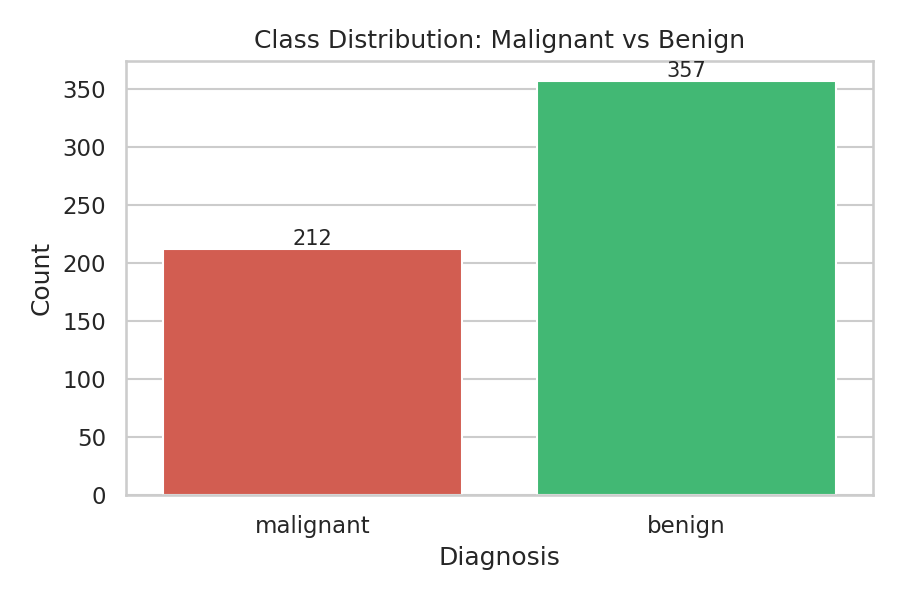

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="diagnosis_label", palette=["#e74c3c", "#2ecc71"])
ax.set_title("Class Distribution: Malignant vs Benign")
plt.tight_layout()
plt.show()

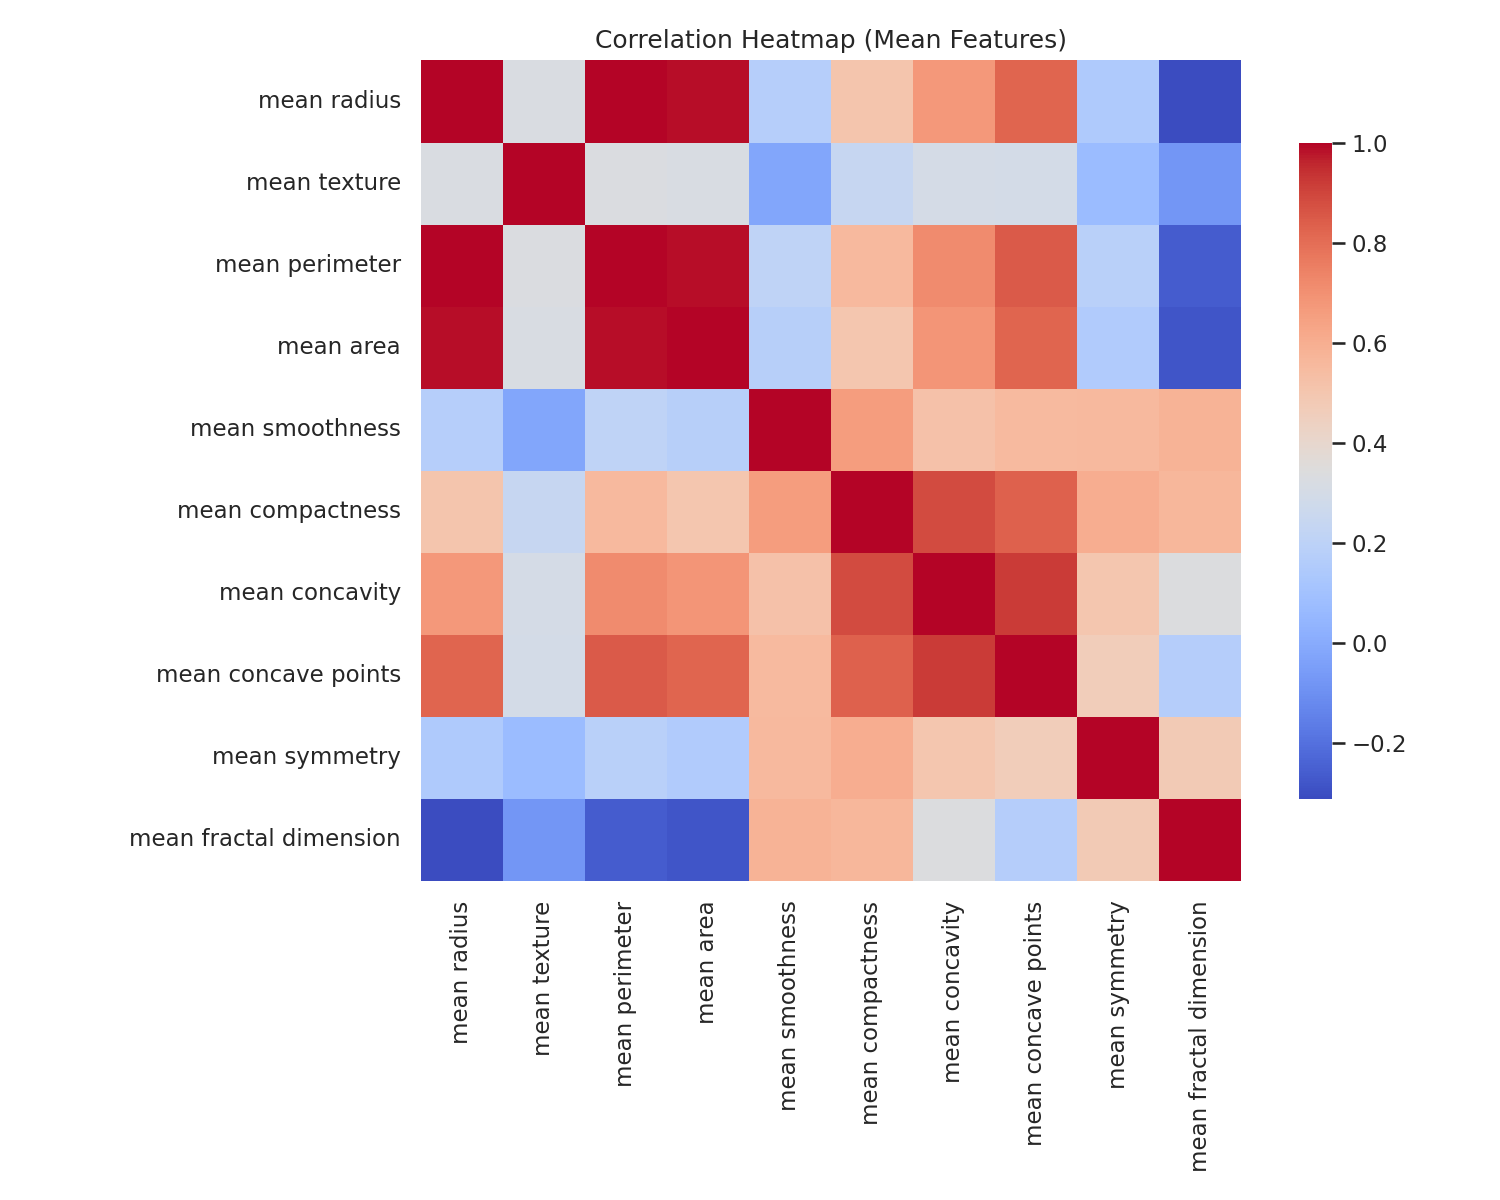

In [7]:
mean_cols = [c for c in df.columns if c.startswith("mean ")]
plt.figure(figsize=(10, 8))
sns.heatmap(df[mean_cols].corr(), cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Mean Features)")
plt.tight_layout()
plt.show()

Several `mean` features (e.g. radius, perimeter, area) are strongly correlated with each other, as expected since they all measure tumor size.

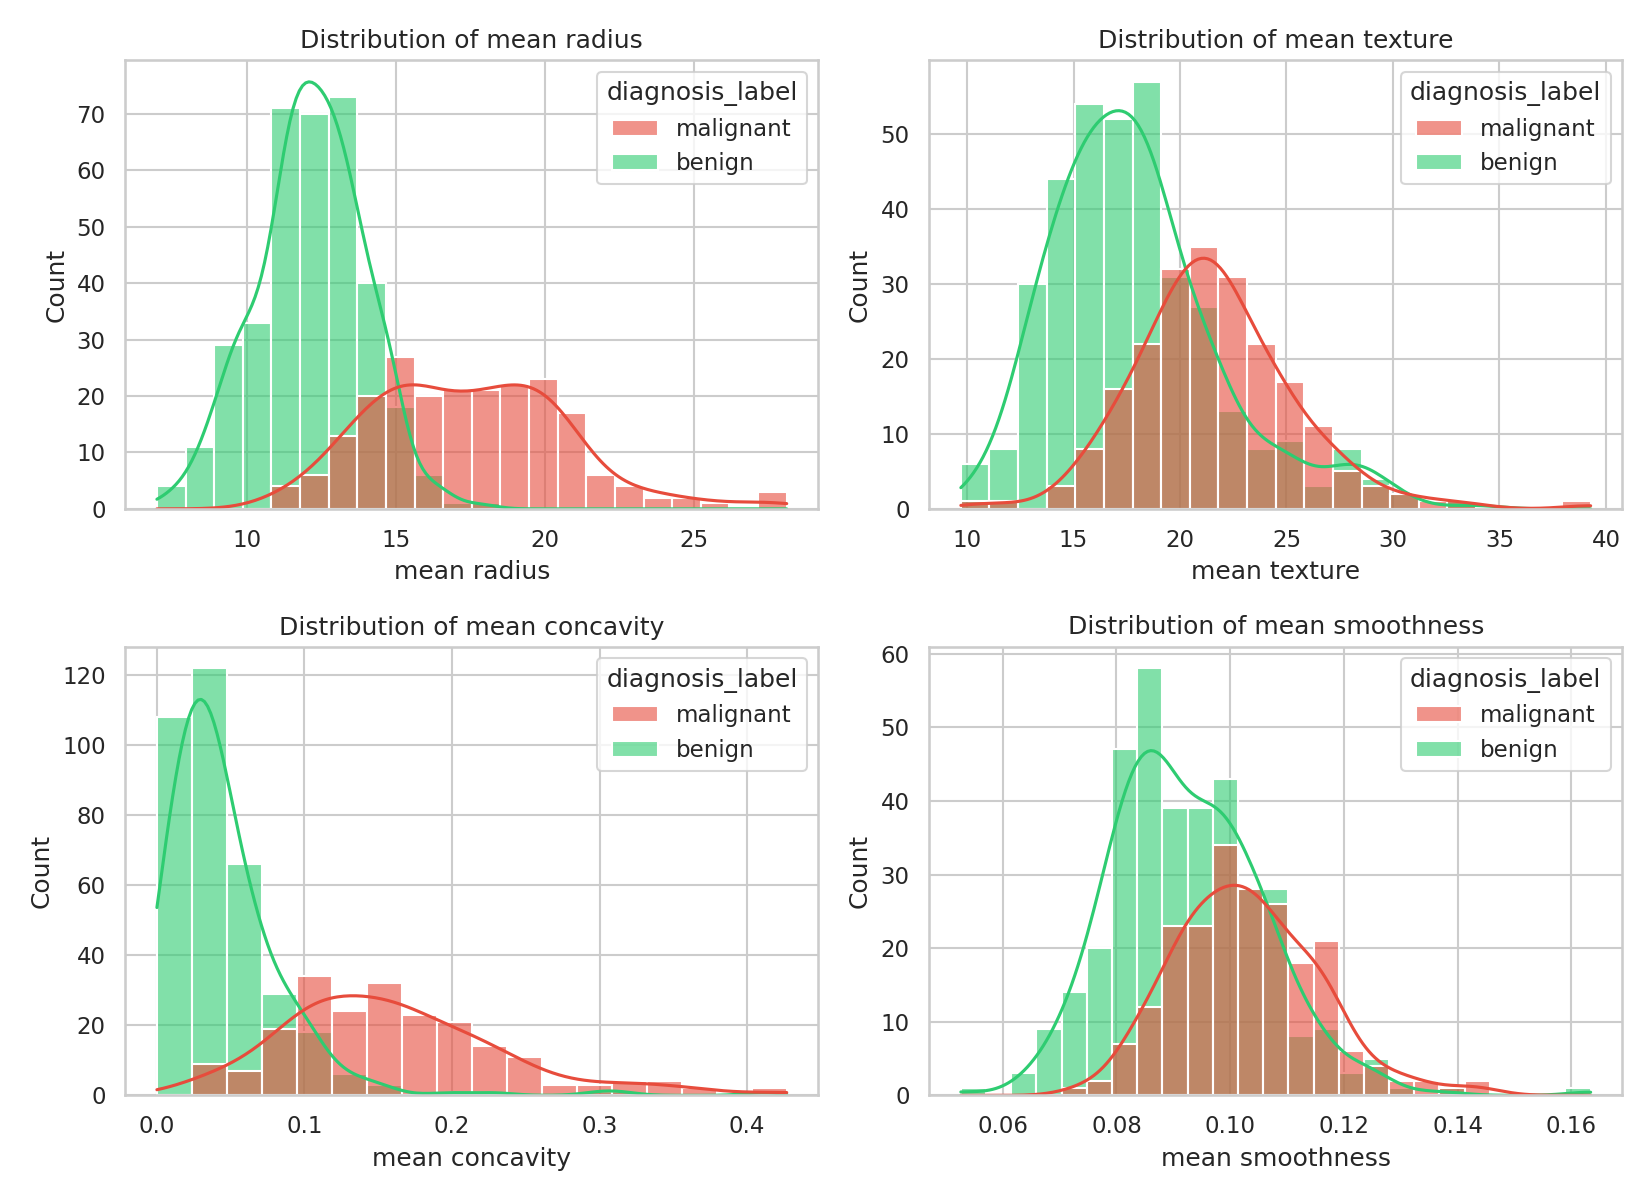

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
dist_feats = ["mean radius", "mean texture", "mean concavity", "mean smoothness"]
for ax, feat in zip(axes.flatten(), dist_feats):
    sns.histplot(data=df, x=feat, hue="diagnosis_label", kde=True, ax=ax,
                 palette=["#e74c3c", "#2ecc3c"], alpha=0.6)
    ax.set_title(f"Distribution of {feat}")
plt.tight_layout()
plt.show()

Malignant tumors tend to have higher mean radius, texture, and concavity values than benign tumors — these are likely to be strong predictive features.

## 4. Data Preprocessing

In [9]:
X = df[bc.feature_names.tolist()]
y = df["diagnosis"]  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train set:", X_train.shape, " Test set:", X_test.shape)

Train set: (455, 30)  Test set: (114, 30)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "../model/scaler.pkl")
print("Feature scaling complete (StandardScaler fit on training data only).")

Feature scaling complete (StandardScaler fit on training data only).


## 5. Model Development
Two supervised classification models are trained and compared: **Logistic Regression** (linear baseline) and **Random Forest** (ensemble, non-linear).

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest


## 6. Model Evaluation

In [12]:
results = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = dict(accuracy=acc, precision=prec, recall=rec, f1_score=f1, roc_auc=auc)

    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("Confusion Matrix:\n", cm, "\n")

--- Logistic Regression ---
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861
ROC-AUC  : 0.9954
Confusion Matrix:
 [[41  1]
 [ 1 71]] 

--- Random Forest ---
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-score : 0.9655
ROC-AUC  : 0.9932
Confusion Matrix:
 [[39  3]
 [ 2 70]] 



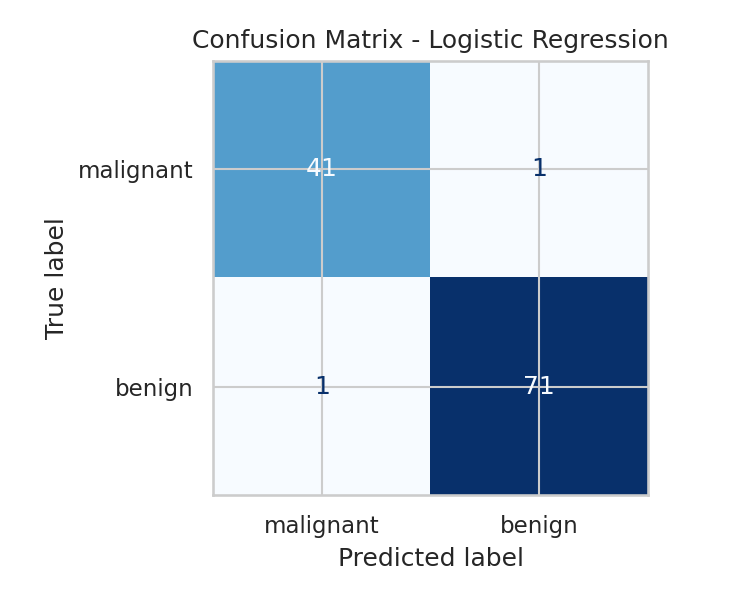

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, trained_models["Logistic Regression"].predict(X_test_scaled),
                                          display_labels=["malignant", "benign"], cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

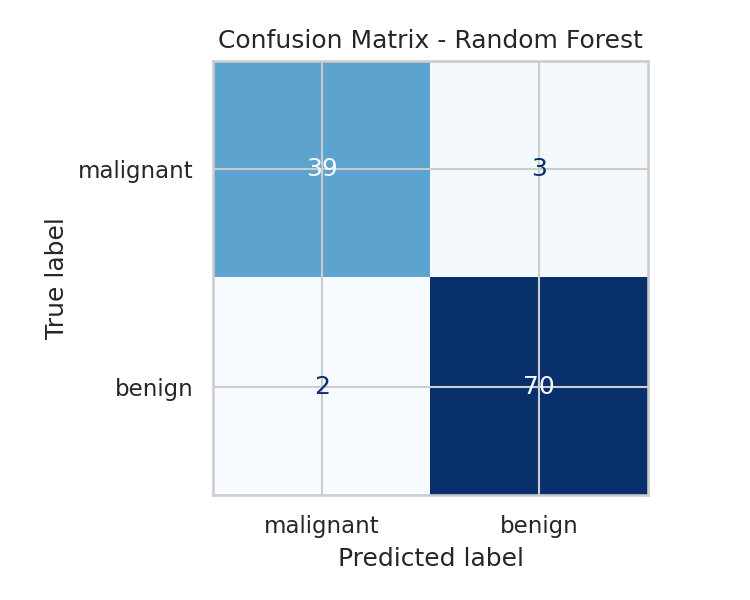

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, trained_models["Random Forest"].predict(X_test_scaled),
                                          display_labels=["malignant", "benign"], cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

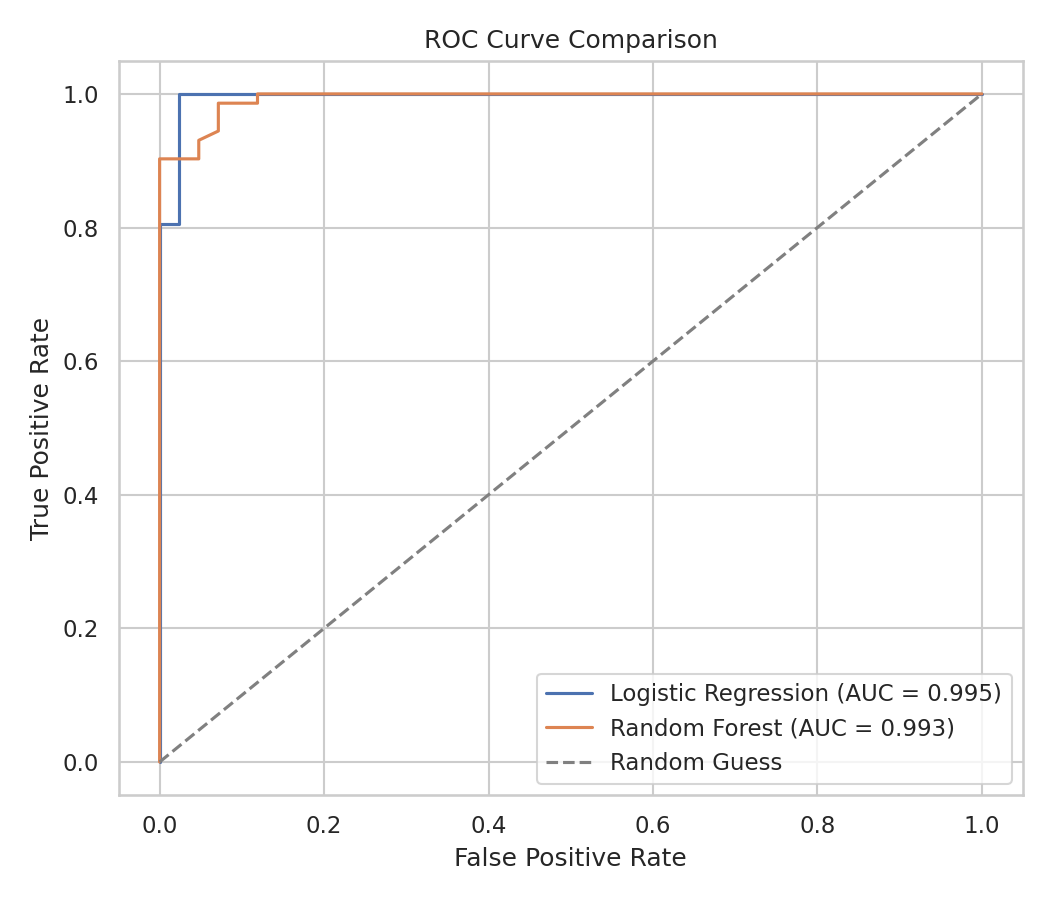

In [15]:
plt.figure(figsize=(7, 6))
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison"); plt.legend()
plt.tight_layout(); plt.show()

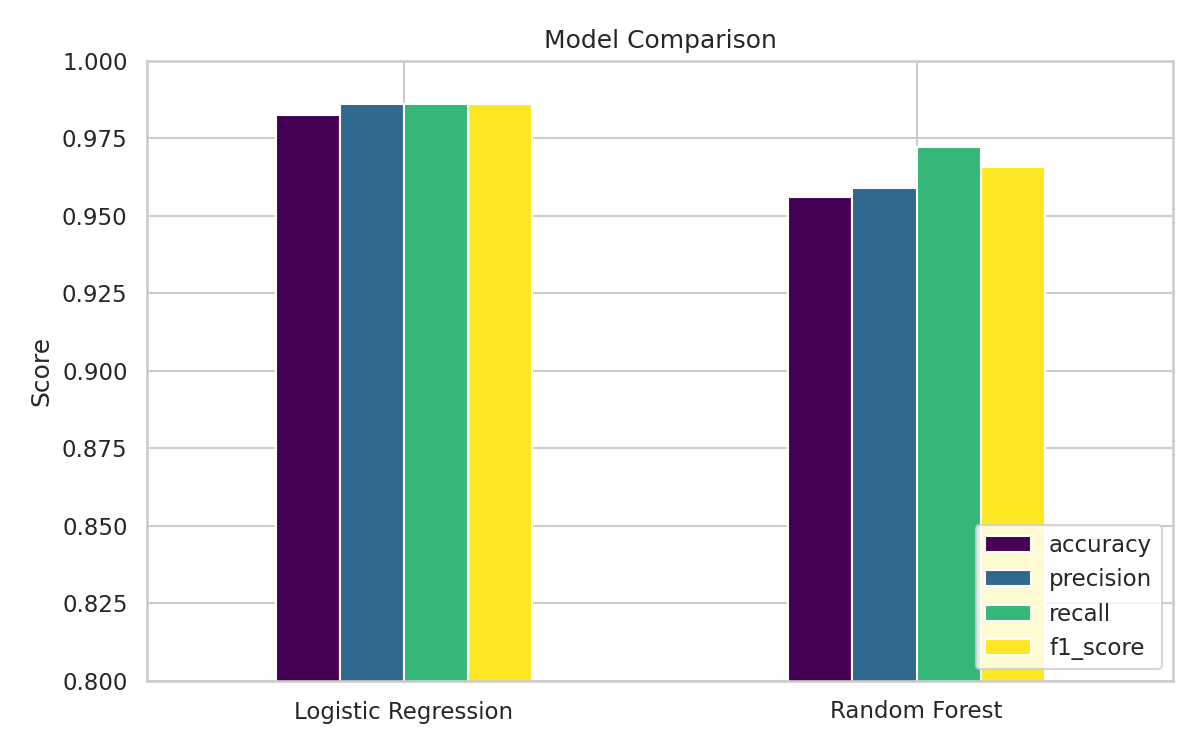

In [16]:
comp_df = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1_score"]]
comp_df.plot(kind="bar", figsize=(8, 5), rot=0, colormap="viridis", ylim=(0.8, 1.0))
plt.title("Model Comparison"); plt.ylabel("Score"); plt.tight_layout(); plt.show()

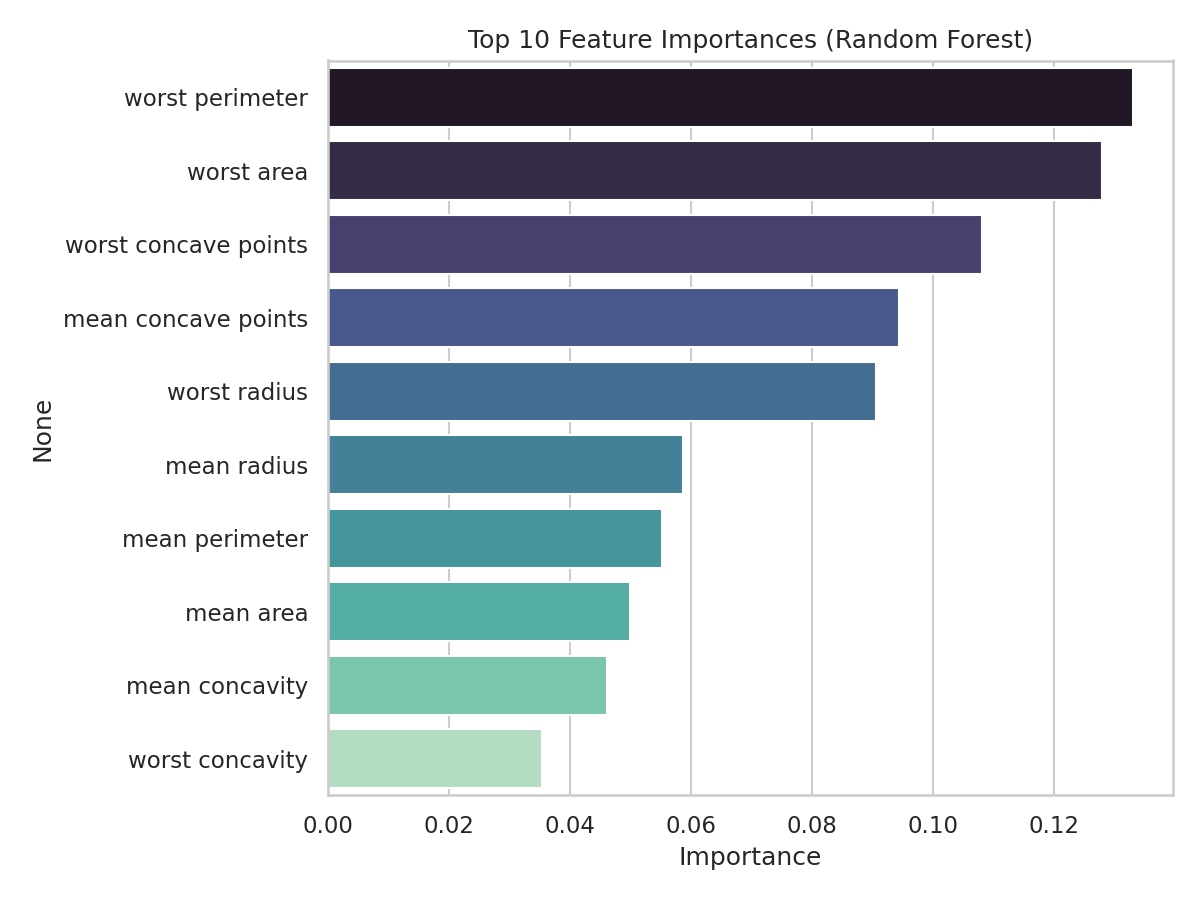

In [17]:
rf = trained_models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

Feature importance analysis shows that measurements like **worst concave points**, **worst perimeter**, and **mean concave points** are the strongest predictors of malignancy, consistent with clinical intuition that irregular, concave cell boundaries are associated with malignant tumors.

## 7. Save Trained Models

In [18]:
for name, model in trained_models.items():
    fname = name.lower().replace(" ", "_")
    joblib.dump(model, f"../model/{fname}_model.pkl")
    print(f"Saved ../model/{fname}_model.pkl")

Saved ../model/logistic_regression_model.pkl
Saved ../model/random_forest_model.pkl


## 8. Conclusion

- Both models achieved strong performance on the held-out test set, with **Logistic Regression** slightly outperforming **Random Forest** on this dataset (Accuracy 98.25% vs 95.61%, F1-score 0.986 vs 0.966).
- The confusion matrices show very few misclassifications (2 total for Logistic Regression, 5 total for Random Forest out of 114 test samples), and both models achieved ROC-AUC scores above 0.99, indicating excellent class separability.
- Feature importance analysis confirms that concavity- and perimeter-related measurements are the most predictive of malignancy, aligning with established medical understanding of tumor morphology.
- **Logistic Regression is selected as the final model** for this problem, based on its slightly higher F1-score, lower variance, and greater interpretability compared to Random Forest.
- A possible limitation is the moderate class imbalance (62.7% benign vs 37.3% malignant); future work could explore resampling techniques (SMOTE) or cost-sensitive learning, as well as cross-validation and hyperparameter tuning (e.g. GridSearchCV) to further validate robustness.

## 9. References

1. Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1995). *Breast Cancer Wisconsin (Diagnostic) Dataset*. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
2. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
3. Kaggle Dataset Mirror: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data